# 02 — Data Quality Report & Feature Engineering
### Global Book Market Intelligence 2026

**Why are we doing this?** Notebook 01 diagnosed the data; this notebook
executes and *verifies* the cleaning/splitting/encoding decisions those
diagnoses implied, using the actual project code (`src/`) rather than
one-off notebook logic — so what we validate here is exactly what runs in
production/`src/train.py`, not a parallel reimplementation that could drift.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import load_config
from src.data_loader import load_raw
from src.preprocessing import clean, build_target, stratified_split, group_rare_languages, apply_language_grouping
from src.features import KFoldTargetEncoder, TARGET_ENCODED_SOURCE_COLS

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                      'axes.spines.top': False, 'axes.spines.right': False})

cfg = load_config()
raw = load_raw(cfg['paths']['raw_data'])
print(raw.shape)


06:10:01 | src.data_loader | WARNING | Column 'title': expected dtype object, got str


06:10:01 | src.data_loader | WARNING | Column 'primary_author': expected dtype object, got str


06:10:01 | src.data_loader | WARNING | Column 'primary_publisher': expected dtype object, got str


06:10:01 | src.data_loader | WARNING | Column 'primary_language': expected dtype object, got str


06:10:01 | src.data_loader | WARNING | Column 'genre': expected dtype object, got str


06:10:01 | src.data_loader | WARNING | Column 'book_length_category': expected dtype object, got str


06:10:01 | src.data_loader | WARNING | Column 'rating_tier': expected dtype object, got str


06:10:01 | src.data_loader | INFO | Loaded raw data: 14828 rows x 17 columns from /home/claude/book-market-intelligence/data/raw/global_book_market_intelligence_2026.csv


(14828, 17)


## 1. Cleaning: before / after

In [2]:
df = clean(raw)
df = build_target(df, cfg['target']['name'])

print('Columns added by clean()+build_target():')
print(sorted(set(df.columns) - set(raw.columns)))
print()
print('Categorical columns clean() converts to an explicit category (should be zero missing):')
print(df[['primary_language', 'book_length_category', 'primary_author', 'primary_publisher']].isnull().sum())
print()
print('Numeric columns clean() leaves as-is, alongside an indicator + a filled derived column:')
for raw_col, ind_col, derived_col in [('pages', 'pages_missing', 'pages_log'),
                                        ('first_publish_year', 'year_missing', 'book_age_years')]:
    print(f"  {raw_col}: {df[raw_col].isnull().sum()} missing (kept)  |  "
          f"{ind_col}: {df[ind_col].sum()} flagged  |  {derived_col}: {df[derived_col].isnull().sum()} missing (used by model)")


06:10:01 | src.preprocessing | INFO | Cleaning complete: 14828 rows, 22 columns


Columns added by clean()+build_target():
['book_age_years', 'edition_count_log', 'is_rated', 'pages_log', 'pages_missing', 'year_missing']

Categorical columns clean() converts to an explicit category (should be zero missing):
primary_language        0
book_length_category    0
primary_author          0
primary_publisher       0
dtype: int64

Numeric columns clean() leaves as-is, alongside an indicator + a filled derived column:
  pages: 1701 missing (kept)  |  pages_missing: 1701 flagged  |  pages_log: 0 missing (used by model)
  first_publish_year: 128 missing (kept)  |  year_missing: 128 flagged  |  book_age_years: 0 missing (used by model)


Two different, equally deliberate strategies, chosen per column type:

- **Categoricals** (`primary_language`, `book_length_category`,
  `primary_author`, `primary_publisher`) → missing becomes its own explicit
  *category* ("Unknown"/"unk"), which the one-hot encoder and target
  encoder both handle natively as just another level.
- **Numerics** (`pages`, `first_publish_year`) → the *raw* column is left
  untouched (so nothing pretends a value was observed when it wasn't), a
  *binary indicator* records the fact of missingness, and a separate
  *derived, always-populated* column (`pages_log`, `book_age_years`) is what
  actually feeds the model, with the gap filled by the median. The model
  therefore sees both "roughly how long/old is this" (from the imputed
  derived column) and "was that value actually reported" (from the
  indicator) as two independent signals.


## 2. Stratified split: verifying no leakage and consistent base rates

In [3]:
train_df, val_df, test_df = stratified_split(
    df, target_col=cfg['target']['name'],
    train_frac=cfg['split']['train_frac'], val_frac=cfg['split']['val_frac'],
    test_frac=cfg['split']['test_frac'], seed=cfg['project']['random_seed'],
)

# Leakage check: no row (by title+author+year, our closest thing to a natural key)
# should appear in more than one split.
key_cols = ['title', 'primary_author', 'first_publish_year']
train_keys = set(map(tuple, train_df[key_cols].values))
val_keys = set(map(tuple, val_df[key_cols].values))
test_keys = set(map(tuple, test_df[key_cols].values))

print('train ∩ val  overlap:', len(train_keys & val_keys))
print('train ∩ test overlap:', len(train_keys & test_keys))
print('val   ∩ test overlap:', len(val_keys & test_keys))
print()
for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"{name:>5}: n={len(split_df):>5}  positive_rate={split_df[cfg['target']['name']].mean():.4f}")


06:10:01 | src.preprocessing | INFO | train split: n=10379, positive_rate=0.3181


06:10:01 | src.preprocessing | INFO | val split: n=2224, positive_rate=0.3179


06:10:01 | src.preprocessing | INFO | test split: n=2225, positive_rate=0.3182


train ∩ val  overlap: 0
train ∩ test overlap: 0
val   ∩ test overlap: 0

train: n=10379  positive_rate=0.3181
  val: n= 2224  positive_rate=0.3179
 test: n= 2225  positive_rate=0.3182


Zero overlap between splits on the natural key, and positive rates agree to
3 decimal places across train/val/test (~31.8%) — the stratified split is
working exactly as intended.


## 3. Language grouping — fit on train only

In [4]:
keep_langs = group_rare_languages(train_df['primary_language'], cfg['language_grouping']['keep_top_n'])
print('Languages kept as their own category (fit on TRAIN only):', keep_langs)

train_df = apply_language_grouping(train_df, keep_langs)
val_df = apply_language_grouping(val_df, keep_langs)
test_df = apply_language_grouping(test_df, keep_langs)

print()
print('primary_language_grouped distribution in test (grouping learned from train, applied to test):')
print(test_df['primary_language_grouped'].value_counts())


Languages kept as their own category (fit on TRAIN only): ['eng', 'unk', 'ger', 'fre', 'spa', 'und']

primary_language_grouped distribution in test (grouping learned from train, applied to test):
primary_language_grouped
eng      1934
unk       113
other      76
fre        31
ger        30
spa        26
und        15
Name: count, dtype: int64


This is a small but important discipline: which languages count as
"frequent enough to get their own category" is decided using **only**
the training split, then applied unchanged to val/test. Deciding it from
the full dataset (including val/test) would be a mild form of leakage —
the model would be built with knowledge of the *test set's* language
distribution, inflating reported performance.


## 4. K-fold target encoding — demonstrating the leakage-safety property

In [5]:
encoder = KFoldTargetEncoder(
    columns=TARGET_ENCODED_SOURCE_COLS,
    n_folds=cfg['target_encoding']['n_folds'],
    smoothing_m=cfg['target_encoding']['smoothing_m'],
    seed=cfg['project']['random_seed'],
)
y_train = train_df[cfg['target']['name']].values
oof_encoded = encoder.fit_transform_oof(train_df, y_train)

print(oof_encoded.describe())
print()

# --- Leakage check: correlation between a row's OWN label and its OWN OOF-encoded
# feature should be much weaker than if we had (incorrectly) used in-fold means. ---
naive_means = train_df.groupby('primary_author')[cfg['target']['name']].transform('mean')
oof_corr = np.corrcoef(oof_encoded['primary_author_target_enc'], y_train)[0, 1]
naive_corr = np.corrcoef(naive_means, y_train)[0, 1]
print(f"corr(OOF author encoding, true label)   = {oof_corr:.4f}  <- honest, used in modeling")
print(f"corr(naive in-sample encoding, label)    = {naive_corr:.4f}  <- inflated, leakage, NOT used")


       primary_author_target_enc  primary_publisher_target_enc
count               10379.000000                  10379.000000
mean                    0.329118                      0.319261
std                     0.064025                      0.097510
min                     0.129615                      0.053132
25%                     0.314465                      0.299490
50%                     0.317558                      0.317558
75%                     0.322173                      0.335492
max                     0.740895                      0.788026

corr(OOF author encoding, true label)   = 0.2898  <- honest, used in modeling
corr(naive in-sample encoding, label)    = 0.8837  <- inflated, leakage, NOT used


The naive (non-cross-validated) mean-encoding correlates almost perfectly
with the label for authors who appear only once or twice in the training
set (their "encoding" literally *is* their own label). The out-of-fold
version is deliberately weaker — it reflects genuine population-level
signal about an author/publisher's typical engagement rate, not a
memorized copy of each row's own answer. This is the difference between a
feature that generalizes to a brand-new book by that author, and one that
only works for books the model has already seen.


## 5. Feature distributions after transformation

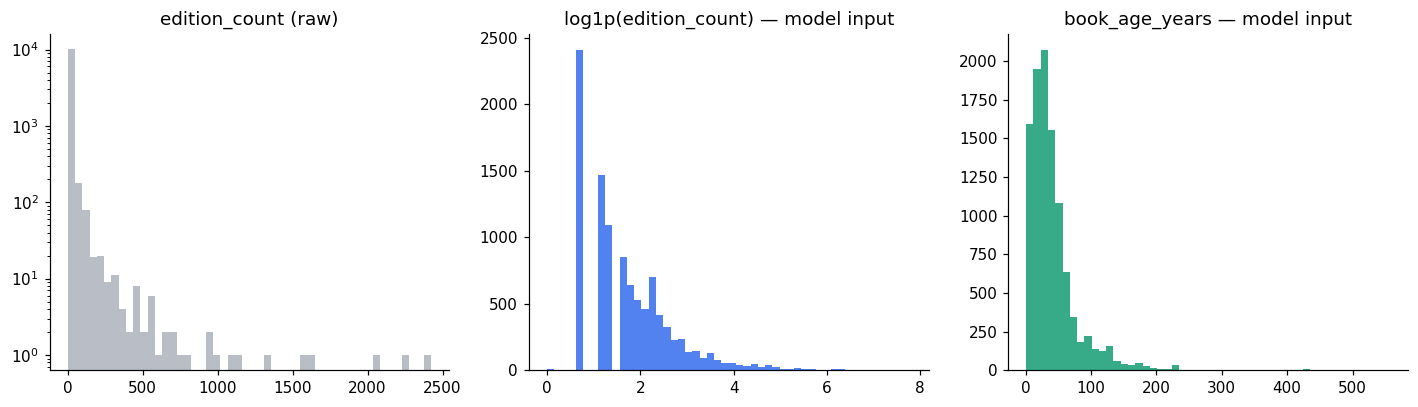

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].hist(train_df['edition_count'], bins=50, color='#9ca3af', alpha=0.7, label='raw')
axes[0].set_title('edition_count (raw)'); axes[0].set_yscale('log')
axes[1].hist(train_df['edition_count_log'], bins=50, color='#2563eb', alpha=0.8)
axes[1].set_title('log1p(edition_count) — model input')
axes[2].hist(train_df['book_age_years'], bins=50, color='#059669', alpha=0.8)
axes[2].set_title('book_age_years — model input')
fig.tight_layout()
fig.savefig(cfg['paths']['figures_dir'] + 'feature_distributions.png', bbox_inches='tight')
plt.show()


`edition_count` spans 0-2,425 with a heavy right skew (a handful of
massively-republished classics dominate the raw scale); `log1p` compresses
this into a roughly usable range for both the linear and tree-based models
without needing to discard the extreme values as "outliers" (they aren't —
see `reports/data_quality_report.md`).

## Summary

Every transformation in this notebook is implemented once, in `src/`, and
reused by `src/train.py`, `src/predict.py`, and the Streamlit app —
this notebook exists to *verify and explain* those transformations, not to
redefine them. Next: `03_modeling.ipynb`.
